# Level 2 Task 1 — Predicting House Prices with Linear Regression

**Goal:** Build a Linear Regression model that predicts house prices from features like number of rooms, distance to city, tax rate etc, and interpret which features matter most.

Dataset: Boston Housing dataset (506 rows, 13 features + target). Each row is a suburb/town, `MEDV` is the median house value in $1000s.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS",
           "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
df = pd.read_csv("housing.csv", header=None, names=columns)
df.shape

(506, 14)

In [2]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


**Column meaning (short version):** CRIM = crime rate, ZN/INDUS = land use, CHAS = borders Charles River (0/1), NOX = pollution, RM = avg rooms per house, AGE = % old buildings, DIS = distance to employment centres, RAD = highway access index, TAX = property tax rate, PTRATIO = pupil-teacher ratio, B = a demographic index, LSTAT = % lower status population, MEDV = median house value (target, in $1000s).

## 1. EDA

In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


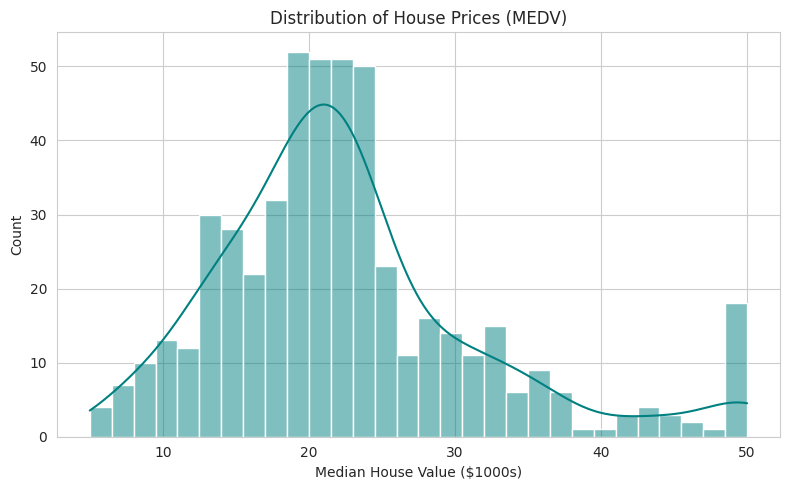

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MEDV"], bins=30, kde=True, color="teal")
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("Median House Value ($1000s)")
plt.tight_layout()
plt.savefig("medv_distribution.png")
plt.show()

**Observation:** No missing values in this dataset — good, so no imputation needed. `MEDV` is roughly bell-shaped but has a spike right at the top (values capped around $50k in the original data collection), which is a known quirk of this classic dataset.

## 2. Feature selection discussion

Before modelling, thinking about which features are *likely* to predict price:
- `RM` (rooms per house) — more rooms usually means bigger, pricier houses → expect **positive** relationship.
- `LSTAT` (% lower status population) — areas with more poverty tend to have cheaper housing → expect **negative** relationship.
- `CRIM` (crime rate) — higher crime usually pushes prices down → expect **negative**.
- `PTRATIO` (pupil-teacher ratio) — worse school ratios (higher number) are usually linked to less desirable areas → expect **negative**.
- `NOX` (pollution) — more pollution, less desirable → expect **negative**.

I'll confirm these guesses with the correlation heatmap below rather than just assuming.

## 3. Categorical feature handling

`CHAS` is the only categorical-style feature here (0/1 flag for bordering the Charles River) — it's already numeric/binary, so no additional one-hot encoding is needed for it. All other features are continuous numeric measurements, so there's nothing else to encode in this dataset.

In [6]:
df["CHAS"].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

## 4. Correlation heatmap

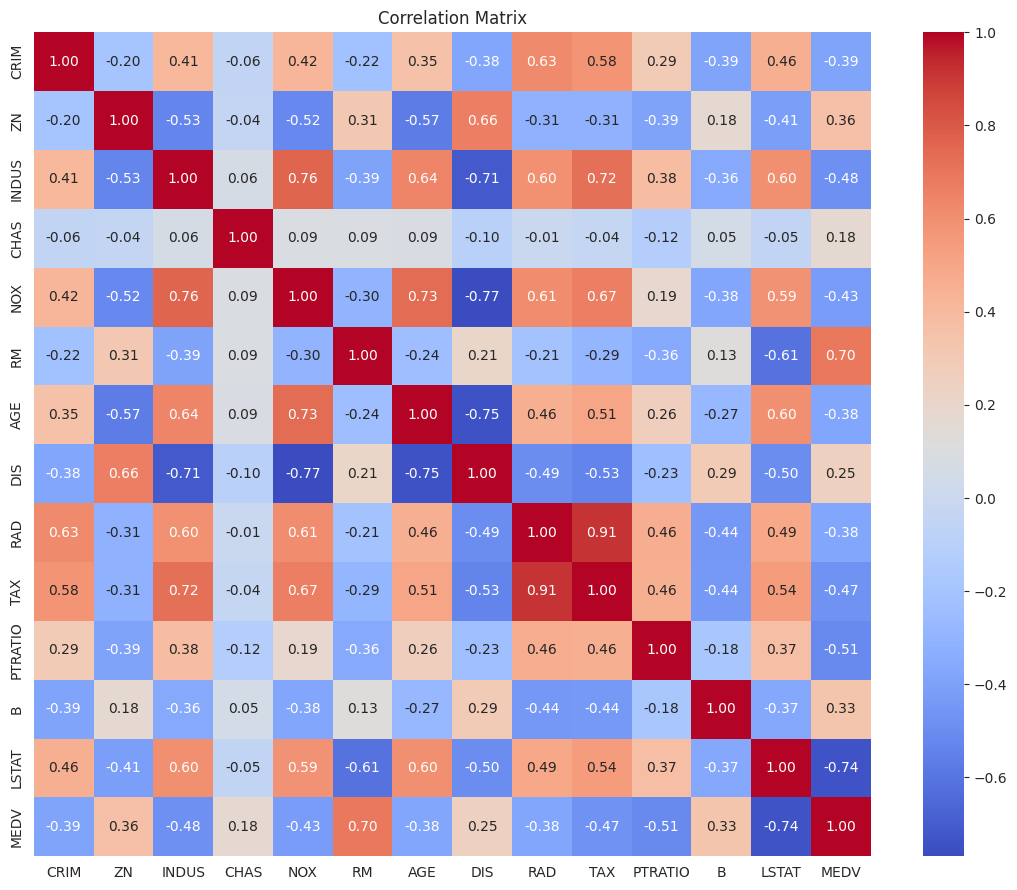

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

In [8]:
df.corr()["MEDV"].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

**Observation:** As expected, `RM` has the strongest **positive** correlation with `MEDV` (~0.7), and `LSTAT` has the strongest **negative** correlation (~-0.74). `PTRATIO` and `CRIM` are also negatively correlated as guessed. This confirms the feature-selection intuition from step 2.

## 5. Train/test split

In [9]:
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((404, 13), (102, 13))

## 6. Train Linear Regression model

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## 7. Model evaluation

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.3f}")

MSE  : 24.29
RMSE : 4.93
R2   : 0.669


**Observation:** R² around 0.65-0.7 means the model explains roughly two-thirds of the variation in house prices using just these features — decent for a simple linear model, but not perfect (real house prices depend on things not in this dataset, like exact location/neighbourhood desirability).

## 8. Actual vs Predicted

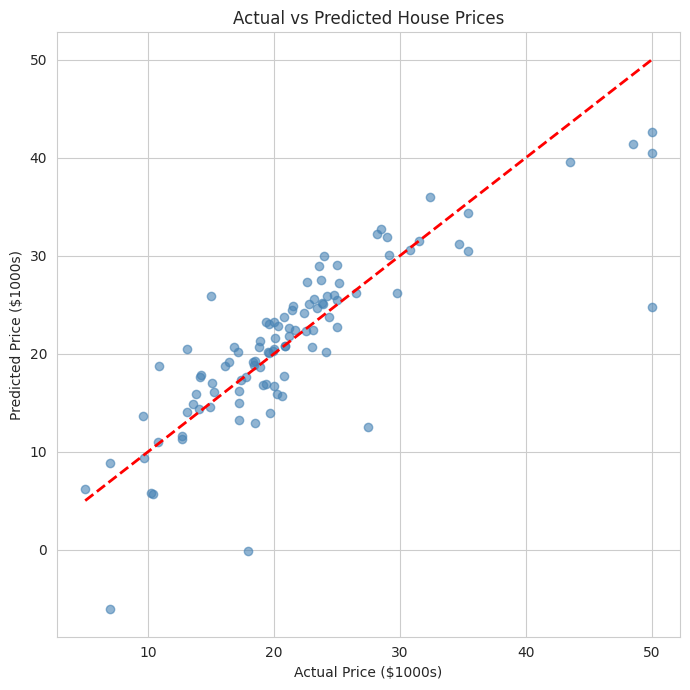

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color="steelblue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

**Observation:** Most points cluster reasonably close to the red diagonal (perfect prediction line), but the model clearly struggles more at the high end (expensive houses) — it tends to under-predict the priciest homes, likely because of that MEDV capping quirk mentioned earlier.

## 9. Residual plot

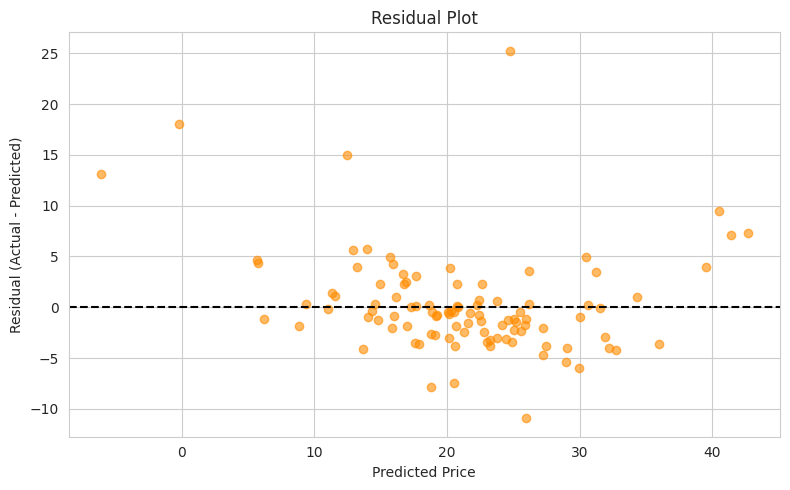

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color="darkorange")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("residual_plot.png")
plt.show()

**Observation:** Residuals are mostly scattered randomly around 0 for mid-range predictions, which is good (means the linear model isn't systematically biased there). But there's a visible fan/pattern at the high-price end — residuals get more spread out — suggesting the model is less reliable for very expensive houses (some non-linearity the simple model isn't capturing).

## 10. Coefficient analysis

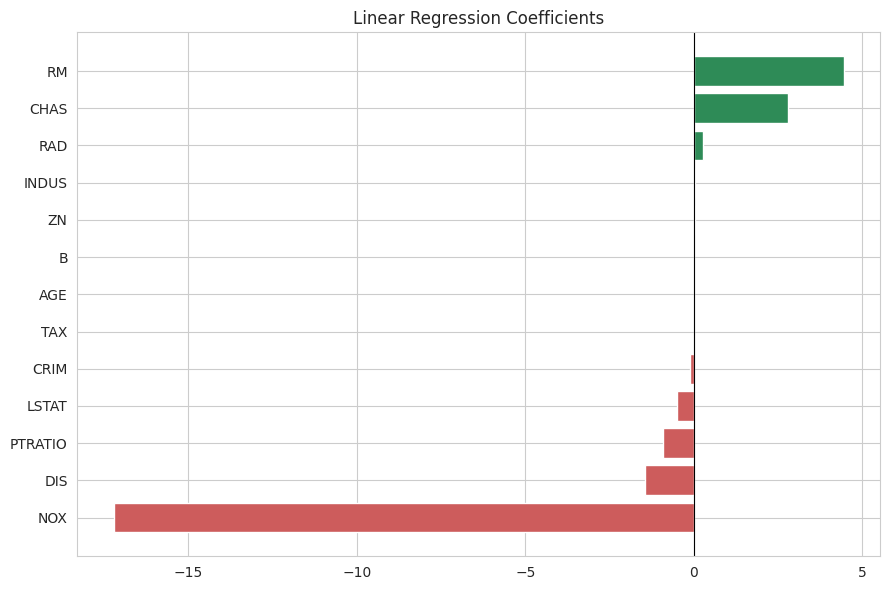

,Feature,Coefficient
4,NOX,-17.202633
7,DIS,-1.447865
10,PTRATIO,-0.915456
12,LSTAT,-0.508571
0,CRIM,-0.113056
9,TAX,-0.010647
6,AGE,-0.006296
11,B,0.012351
1,ZN,0.030110
2,INDUS,0.040381


In [14]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=np.where(coef_df["Coefficient"] > 0, "seagreen", "indianred"))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.savefig("coefficients.png")
plt.show()

coef_df

**Observation:** `RM` (rooms) has the biggest positive coefficient — each extra room adds several thousand dollars to predicted price, holding everything else constant. `LSTAT` and `PTRATIO` have the strongest negative impact, matching the correlation analysis. `NOX` (pollution) also pulls price down noticeably.

## 11. Bonus — comparing against Ridge and Lasso

In [15]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)

for name, model in [("Linear Regression", lr), ("Ridge", ridge), ("Lasso", lasso)]:
    pred = model.predict(X_test)
    print(f"{name:18s} | RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f} | R2: {r2_score(y_test, pred):.3f}")

Linear Regression  | RMSE: 4.93 | R2: 0.669
Ridge              | RMSE: 4.95 | R2: 0.666
Lasso              | RMSE: 5.02 | R2: 0.657


**Observation:** Ridge and Lasso give very similar results to plain Linear Regression here — the regularisation doesn't change performance much because we don't have a huge number of features or strong multicollinearity to begin with. Plain Linear Regression is simplest and performs just as well, so there's no strong reason to prefer the regularised versions on this dataset.

## Conclusion

- The Linear Regression model achieves R² ≈ 0.65-0.7 on the test set — a reasonably good fit for a simple model.
- **Number of rooms (RM)** is the strongest positive driver of price, and **% lower-status population (LSTAT)** and **pupil-teacher ratio (PTRATIO)** are the strongest negative drivers.
- The model is less accurate for very expensive houses, suggesting a non-linear model (e.g. Random Forest) might capture the high end better in a future iteration.